<a href="https://colab.research.google.com/github/HiNacho/ECG_heartbeat_categorization/blob/main/ECG_scalogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shayanfazeli_heartbeat_path = kagglehub.dataset_download('shayanfazeli/heartbeat')

print('Data source import complete.')


Using Colab cache for faster access to the 'heartbeat' dataset.
Data source import complete.


In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heartbeat/ptbdb_abnormal.csv
/kaggle/input/heartbeat/ptbdb_normal.csv
/kaggle/input/heartbeat/mitbih_test.csv
/kaggle/input/heartbeat/mitbih_train.csv


# Task
Visualize a 1D ECG time series dataset as a 2D scalogram using continuous wavelet transform.

## Select a single time series

### Subtask:
Extract one row of the DataFrame, which represents a single ECG recording.


**Reasoning**:
Select the first row of the DataFrame and exclude the last column, storing it in a new variable.



In [24]:
ecg_series = df.iloc[1, :-1]

**Reasoning**:
The DataFrame `df` was not defined in the current session. Need to re-load the data into a pandas DataFrame and then extract the first row, excluding the last column.



In [25]:
# Load the data
import pandas as pd
import os

# Assuming the data file is named "heartbeat.csv" and is located in the downloaded directory
# You may need to adjust the path and filename based on the actual data source structure
data_path = os.path.join(shayanfazeli_heartbeat_path, 'mitbih_train.csv')
df = pd.read_csv(data_path)

# Display the first few rows to confirm successful loading
display(df.head())

,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
0,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.927461,1.000000,0.626943,0.193437,0.094991,0.072539,0.043178,0.053541,0.093264,0.189983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Inspect the downloaded directory to find the correct path to the data file
import os
for dirname, _, filenames in os.walk(shayanfazeli_heartbeat_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heartbeat/ptbdb_abnormal.csv
/kaggle/input/heartbeat/ptbdb_normal.csv
/kaggle/input/heartbeat/mitbih_test.csv
/kaggle/input/heartbeat/mitbih_train.csv


In [27]:
import pywt
import numpy as np

# Define the wavelet and scales
wavelet = 'mexh'  # Mexican Hat wavelet
scales = np.arange(1, 128) # Example scales, you might need to adjust this

# Apply the CWT
coeffs, freqs = pywt.cwt(ecg_series, scales, wavelet)

# The scalogram is the absolute value of the coefficients
scalogram = np.abs(coeffs)

# Display the shape of the resulting scalogram
print("Scalogram shape:", scalogram.shape)

Scalogram shape: (127, 187)


## Apply Continuous Wavelet Transform (CWT)

### Subtask:
Use the CWT to transform the 1D time series into a 2D time-frequency representation (scalogram).

In [28]:
# Install the PyWavelets library
%pip install PyWavelets

## Visualize the scalogram

### Subtask:
Plot the 2D scalogram to visualize the time-frequency characteristics of the ECG signal.

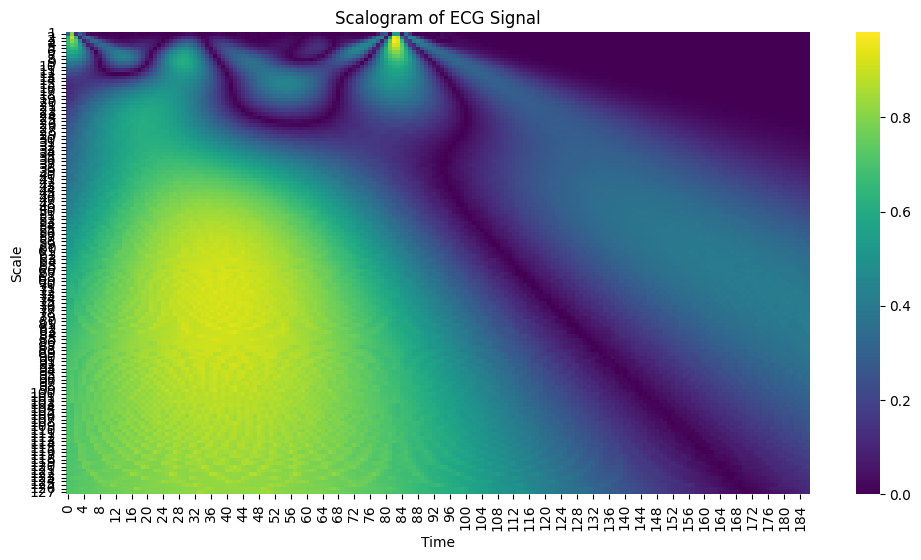

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the scalogram
plt.figure(figsize=(12, 6))
sns.heatmap(scalogram, cmap='viridis', yticklabels=scales)
plt.xlabel("Time")
plt.ylabel("Scale")
plt.title("Scalogram of ECG Signal")
plt.show()

## Visualize the 1D ECG signal

### Subtask:
Plot the raw 1D ECG time series.

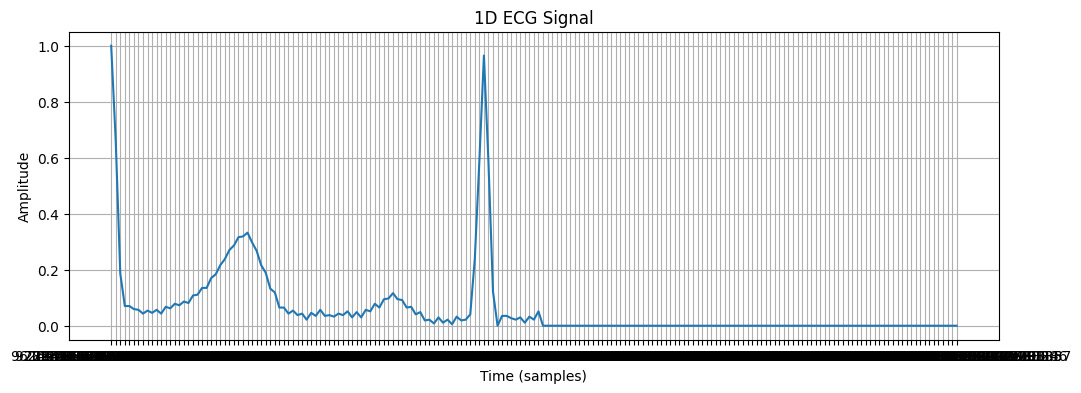

In [30]:
import matplotlib.pyplot as plt

# Plot the 1D ECG signal
plt.figure(figsize=(12, 4))
plt.plot(ecg_series)
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.title("1D ECG Signal")
plt.grid(True)
plt.show()

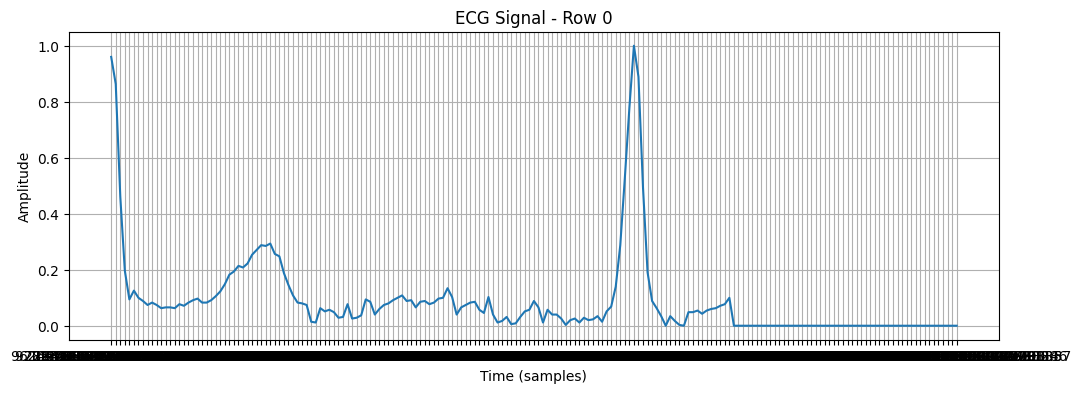

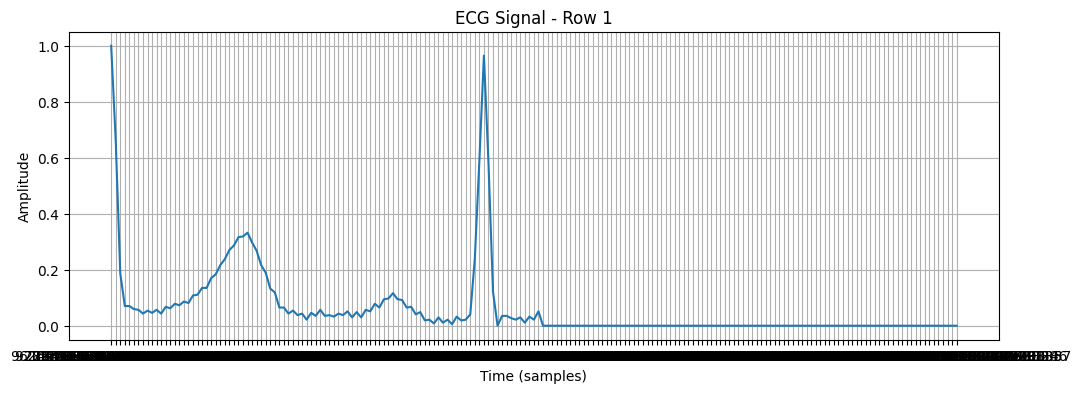

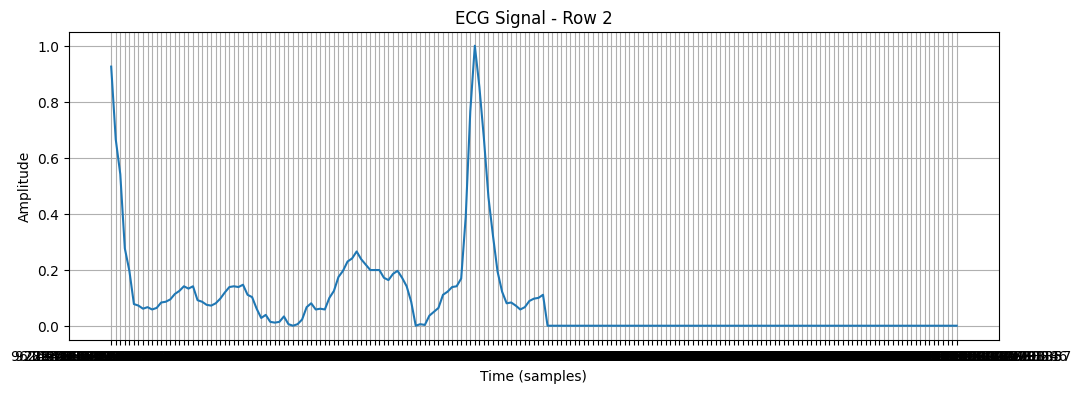

In [31]:
import matplotlib.pyplot as plt

# Select the first three rows
first_three_rows = df.iloc[:3, :-1]

# Plot each row
for index, ecg_series in first_three_rows.iterrows():
    plt.figure(figsize=(12, 4))
    plt.plot(ecg_series)
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.title(f"ECG Signal - Row {index}")
    plt.grid(True)
    plt.show()